# Bacterial DNA Isolation, Purification & Quantification for PCR

**Technique:** Genomic DNA extraction, spectrophotometric quality control
**Objective:** Evaluate NanoDrop-style A260/A280 readings for extracted bacterial
DNA samples, flag which are suitable as PCR template, and calculate the dilution
needed to reach a standard working concentration.

---
## 1. Background

Bacterial DNA extraction involves lysis, purification (protein/RNA removal), and
precipitation. Because PCR is highly sensitive to inhibitors, extracted DNA must
be checked for both concentration and purity (A260/A280 ratio) before use as
template.

| A260/A280 | Interpretation |
|---|---|
| ~1.8 | High-purity DNA — suitable for PCR |
| < 1.8 | Protein/phenol contamination |
| > 2.0 | Possible RNA contamination |


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sample_data/nanodrop_readings.csv")
df

,sample_id,concentration_ng_ul,a260,a280
0,Sample_1,145.2,2.904,1.587
1,Sample_2,88.6,1.772,1.166
2,Sample_3,210.4,4.208,1.957
3,Sample_4,62.1,1.242,0.690
4,Sample_5,175.8,3.516,1.953


## 2. Calculate A260/A280 purity ratio

In [2]:
df["a260_a280_ratio"] = (df.a260 / df.a280).round(2)
df[["sample_id", "concentration_ng_ul", "a260_a280_ratio"]]

,sample_id,concentration_ng_ul,a260_a280_ratio
0,Sample_1,145.2,1.83
1,Sample_2,88.6,1.52
2,Sample_3,210.4,2.15
3,Sample_4,62.1,1.80
4,Sample_5,175.8,1.80


## 3. Assess PCR suitability

In [3]:
def assess_purity(ratio):
    if 1.75 <= ratio <= 1.90:
        return "Suitable for PCR"
    elif ratio < 1.75:
        return "Protein contamination"
    else:
        return "Possible RNA contamination"

TARGET_CONC = 20.0  # ng/uL standard PCR working concentration

def dilution(conc, target=TARGET_CONC):
    if conc <= target:
        return "Use neat"
    return f"1:{conc/target:.1f} in NFW"

df["status"] = df.a260_a280_ratio.apply(assess_purity)
df["dilution_to_20ng_ul"] = df.concentration_ng_ul.apply(dilution)
df[["sample_id", "concentration_ng_ul", "a260_a280_ratio", "status", "dilution_to_20ng_ul"]]

,sample_id,concentration_ng_ul,a260_a280_ratio,status,dilution_to_20ng_ul
0,Sample_1,145.2,1.83,Suitable for PCR,1:7.3 in NFW
1,Sample_2,88.6,1.52,Protein contamination,1:4.4 in NFW
2,Sample_3,210.4,2.15,Possible RNA contamination,1:10.5 in NFW
3,Sample_4,62.1,1.80,Suitable for PCR,1:3.1 in NFW
4,Sample_5,175.8,1.80,Suitable for PCR,1:8.8 in NFW


## 4. Visualise purity across samples

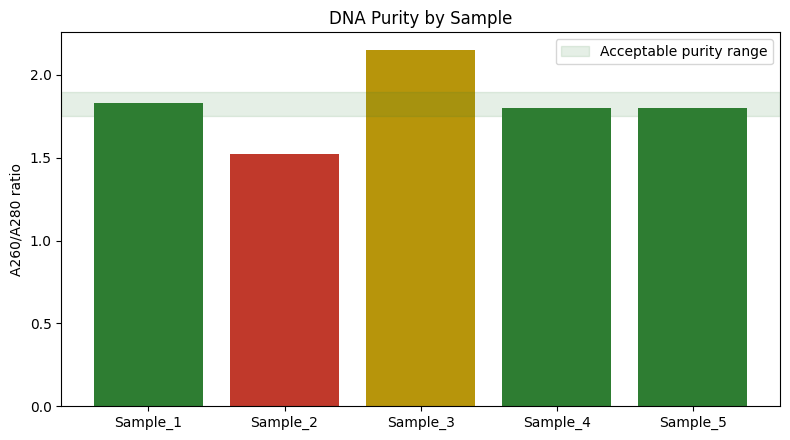

In [4]:
color_map = {"Suitable for PCR": "#2E7D32", "Protein contamination": "#C0392B",
             "Possible RNA contamination": "#B7950B"}
colors = df.status.map(color_map)

plt.figure(figsize=(8, 4.5))
plt.bar(df.sample_id, df.a260_a280_ratio, color=colors)
plt.axhspan(1.75, 1.90, color="#2E7D32", alpha=0.12, label="Acceptable purity range")
plt.ylabel("A260/A280 ratio")
plt.title("DNA Purity by Sample")
plt.legend()
plt.tight_layout()
plt.savefig("dna_purity_plot.png", dpi=150)
plt.show()

## 5. Summary

Samples with an A260/A280 ratio between 1.75 and 1.90 are considered high-purity
and suitable as PCR template DNA. Samples outside this range should be re-purified
(additional phenol-chloroform extraction or ethanol wash) before use, since residual
protein or RNA can inhibit or reduce the efficiency of downstream PCR amplification.
